In [1]:
pip install torch

  Using cached torch-2.13.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached cuda_bindings-13.3.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.7.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Usin

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot |as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# Use data from following link: https://archive.ics.uci.edu/dataset/53/iris
# Layers are fully connected (fc).

In [5]:
# Create class that inherits nn.Module

class Model(nn.Module):
  # Input layer (4 features of the flower) --> Hidden layer 1 --> H2 --> output (3 classes of flowers)
  def __init__(self, in_features = 4, h1 = 8, h2 = 9, out_features = 3):
    super().__init__()                                            # Instantiate our nn.Module (just gotta put it there ...)
    self.fc1 = nn.Linear(in_features,h1)                          # Notice the pattern...
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2,out_features)

  # Now create a function that moves stuff forward
  def forward(self, x):
    x = F.relu(self.fc1(x))                                       # relu makes anything less than zero is zero, anything bigger than zero is just whatever it is.
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [6]:
# Pick a manual seed for randomization (and compare results easier)
torch.manual_seed(41)
model = Model()

In [9]:
# Let's load data and train our Neural network:

url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_dataframe = pd.read_csv(url)

# Let's change the different flower classes for numbers:
  # setosa -> 0.0
  # versicolor -> 1.0
  # virginica -> 2.0

my_dataframe['species'] = my_dataframe['species'].replace('setosa', 0.0)
my_dataframe['species'] = my_dataframe['species'].replace('versicolor', 1.0)
my_dataframe['species'] = my_dataframe['species'].replace('virginica', 2.0)

/tmp/ipykernel_1182/2570116834.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_dataframe['species'] = my_dataframe['species'].replace('virginica', 2.0)


In [10]:
# Train test split! Set X (features), y (species (aka labels))
X = my_dataframe.drop('species', axis = 1)
y = my_dataframe['species']

# Convert to numpy arrays:
X = X.values
y = y.values

In [11]:
 # Train test split!

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.2, random_state = 41) # No need for the random state, that's just to verify answer

# Run the following line to make sure I understand what the RHS of above is doing:
# train_test_split(X,y, test_size = 0.2, random_state = 41)

In [12]:
# Convert features to float tensor to train data
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# Convert y labels to long tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [13]:
# Set the criterion of model to measure the error, how far off predictions are from the data

criterion = nn.CrossEntropyLoss()

# Choose optimizer (in this case Adam) ... pretty self explenatory, learning rate (if error doesnt go down after a bunch of epochs, lower learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # The longer the learning rate, the longer it takes to learn...

print(model.parameters) # basically our layers!

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>


In [14]:
# Let's train our model.
epochs = 100
losses = []

range
for i in range(epochs):
  # Go forward and get a prediction
  y_prediction = model.forward(X_train) # Get predicted results

  # Measure the loss/error:
  loss = criterion(y_prediction,y_train)

  # Keep track of our losses:
  losses.append(loss.detach().numpy())

  # print every 10 epochs:
  if i % 10 == 0:
    print(f'Epoch {i} and loss {loss}')

  # Do back propagation: take error rate of forward propagation and feed it back though the network to fine tune the weights.
  # Here is the key part for the neuron to learn... uses calculus and derivatives to find right answer.
  optimizer.zero_grad()
  loss.backward()     # Here is where the learning occurs
  optimizer.step()


Epoch 0 and loss 1.1251550912857056
Epoch 10 and loss 1.0096259117126465
Epoch 20 and loss 0.8157405853271484
Epoch 30 and loss 0.585706353187561
Epoch 40 and loss 0.3999636471271515
Epoch 50 and loss 0.2676880657672882
Epoch 60 and loss 0.17942363023757935
Epoch 70 and loss 0.12151690572500229
Epoch 80 and loss 0.0860118418931961
Epoch 90 and loss 0.06520850956439972


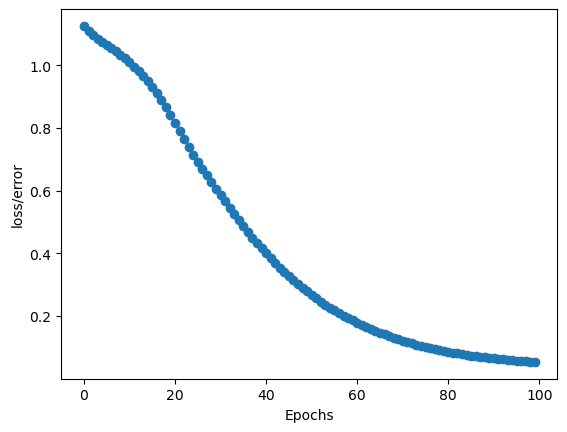

In [15]:
# Graph it out!
plt.scatter(range(epochs),losses)
plt.ylabel('loss/error')
plt.xlabel('Epochs')
plt.show()

In [16]:
# Let's evaluate model on test data
with torch.no_grad():                     # turn off back propagation
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)        # Find the loss or error

In [17]:
loss

tensor(0.1315)

In [18]:
# Not a great number above, so:
correct = 0

with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    print(f'{i+1}.) {str(y_val)} \t {y_val.argmax().item()} \t {y_test[i]}')

    # Correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} correct')



1.) tensor([-5.8760,  4.4628,  6.5124]) 	 2 	 2
2.) tensor([-7.5436,  4.1670,  9.7255]) 	 2 	 2
3.) tensor([-8.4504,  5.1271, 10.1987]) 	 2 	 2
4.) tensor([-4.3398,  5.6267,  2.5608]) 	 1 	 1
5.) tensor([-7.1825,  4.8754,  8.2992]) 	 2 	 2
6.) tensor([-3.3974,  5.3463,  1.2803]) 	 1 	 1
7.) tensor([-5.9231,  4.9822,  5.9997]) 	 2 	 2
8.) tensor([-4.2881,  5.7003,  2.3889]) 	 1 	 1
9.) tensor([-6.5356,  4.9257,  7.1260]) 	 2 	 2
10.) tensor([-8.0509,  4.4129, 10.3286]) 	 2 	 2
11.) tensor([-5.6762,  4.9500,  5.6215]) 	 2 	 2
12.) tensor([ 4.5662, -2.2476, -2.8911]) 	 0 	 0
13.) tensor([ 4.2571, -1.9967, -2.7330]) 	 0 	 0
14.) tensor([-2.1108,  4.0515,  0.5799]) 	 1 	 1
15.) tensor([ 3.4575, -1.2098, -2.3514]) 	 0 	 0
16.) tensor([-5.4724,  5.1165,  5.0934]) 	 1 	 2
17.) tensor([ 4.0557, -1.7949, -2.6492]) 	 0 	 0
18.) tensor([-5.8075,  4.6053,  6.2458]) 	 2 	 1
19.) tensor([ 4.4343, -2.1392, -2.8242]) 	 0 	 0
20.) tensor([ 3.4527, -1.2514, -2.3660]) 	 0 	 0
21.) tensor([-2.6189,  4.5619

In [19]:
# Let's evaluate new data on the network

new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

# To the network, this is no different than test data! It is data that it hasn't seen yet and it makes a "guess" (not really)

In [20]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 4.5365, -2.2383, -2.8684])
